<a href="https://colab.research.google.com/github/naol-shumi/pandas-revision/blob/main/pandasrevision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Task 1: Load & Explore Data

import pandas as pd

# Load dataset with encoding fix
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Check data types and dataset structure
print("\nDataset Info:")
print(df.info())

# Generate summary statistics
print("\nSummary Statistics:")
print(df.describe(include="all"))


First 5 rows of the dataset:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Cat

# Task 2: Data Cleaning

## Insights

1. **Missing Values**
   - Identified columns with missing entries.
   - Ensured data integrity by either dropping incomplete rows or filling values (e.g., using mean for numeric fields).
   - This step prevents errors in later analysis and ensures consistency.

2. **Data Type Conversion**
   - Converted `Order Date` and `Ship Date` into proper `datetime` format.
   - This enables time-based analysis such as trends, seasonality, and shipping performance.

3. **Cleaned Dataset**
   - The resulting dataset (`df_cleaned`) is free of missing values and has correctly formatted columns.
   - This prepares the data for reliable exploratory analysis and visualization.

## Why It Matters
- Clean data reduces bias and errors in analysis.
- Proper date formatting unlocks powerful time-series insights.
- Handling missing values ensures statistical summaries and visualizations are accurate.


In [8]:
# Task 2: Data Cleaning

import pandas as pd

# Load dataset with encoding fix
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# 1. Identify missing values
print("Missing values per column:")
print(df.isnull().sum())

# 2. Handle missing data
# Option A: Drop rows with missing values
df_cleaned = df.dropna()

# Option B: Fill missing values (example: numeric columns with mean)
# df_cleaned = df.fillna(df.mean(numeric_only=True))

print("\nAfter handling missing data:")
print(df_cleaned.isnull().sum())

# 3. Convert relevant columns to correct data types
# Convert Order Date and Ship Date to datetime
df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], errors='coerce')
df_cleaned['Ship Date'] = pd.to_datetime(df_cleaned['Ship Date'], errors='coerce')

print("\nData types after conversion:")
print(df_cleaned.dtypes)


Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

After handling missing data:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data types after conversion:
Row ID                    int64
Order ID                 object
Order Date       datetime

Task 3: Feature Engineering

 Insights
1. **Date Features**
   - Extracted `Order Month` and `Order Year` from `Order Date`.
   - Enables analysis of seasonal trends and yearly performance.

2. **Profit Margin**
   - Created a new column: `Profit Margin = Profit / Sales`.
   - This metric highlights efficiency and profitability across categories, regions, and segments.

3. **Verification**
   - Checked sample rows and summary statistics to confirm logical correctness.
   - Ensures new features are reliable for deeper analysis.

 Why It Matters
- Feature engineering adds analytical depth beyond raw columns.
- Time features allow trend analysis.
- Profit margin provides a normalized measure of performance, useful for comparisons.


In [9]:
# Task 3: Feature Engineering

import pandas as pd

# Load cleaned dataset (with encoding fix)
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Convert Order Date to datetime if not already done
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# 1. Extract Month and Year from Order Date
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

# 2. Create a new column based on existing numerical columns
# Example: Profit Margin = Profit / Sales
df['Profit Margin'] = df['Profit'] / df['Sales']

# 3. Verify new column logic
print("First 5 rows with new features:")
print(df[['Order Date', 'Order Month', 'Order Year', 'Sales', 'Profit', 'Profit Margin']].head())

# Check summary statistics of new column
print("\nProfit Margin Summary:")
print(df['Profit Margin'].describe())


First 5 rows with new features:
  Order Date  Order Month  Order Year     Sales    Profit  Profit Margin
0 2016-11-08           11        2016  261.9600   41.9136         0.1600
1 2016-11-08           11        2016  731.9400  219.5820         0.3000
2 2016-06-12            6        2016   14.6200    6.8714         0.4700
3 2015-10-11           10        2015  957.5775 -383.0310        -0.4000
4 2015-10-11           10        2015   22.3680    2.5164         0.1125

Profit Margin Summary:
count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64


 Task 4: GroupBy & Aggregation

 Insights
1. **Sales by Category**
   - Summarized total sales across product categories.
   - Helps identify which categories drive revenue.

2. **Profit by Region**
   - Aggregated profit by region.
   - Highlights geographic strengths and weaknesses.

3. **Top Customers**
   - Ranked customers by total sales.
   - Useful for loyalty programs and targeted marketing.

4. **Monthly Sales Trends**
   - Grouped sales by month to reveal time-based patterns.
   - Enables detection of seasonality and growth trends.

 Why It Matters
- GroupBy and aggregation provide high-level insights from raw data.
- Helps prioritize strategies by category, region, and customer.
- Time-based trends guide forecasting and inventory planning.


In [10]:
# Task 4: GroupBy & Aggregation

import pandas as pd

# Load dataset with encoding fix
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Ensure Order Date is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# 1. Calculate total sales by category
sales_by_category = df.groupby('Category')['Sales'].sum().reset_index()
print("Total Sales by Category:")
print(sales_by_category)

# 2. Calculate total profit by region
profit_by_region = df.groupby('Region')['Profit'].sum().reset_index()
print("\nTotal Profit by Region:")
print(profit_by_region)

# 3. Identify top 5 customers based on sales
top_customers = df.groupby('Customer Name')['Sales'].sum().reset_index()
top_customers = top_customers.sort_values(by='Sales', ascending=False).head(5)
print("\nTop 5 Customers by Sales:")
print(top_customers)

# 4. Analyze sales trends over time (monthly)
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()
print("\nMonthly Sales Trends:")
print(monthly_sales)


Total Sales by Category:
          Category        Sales
0        Furniture  741999.7953
1  Office Supplies  719047.0320
2       Technology  836154.0330

Total Profit by Region:
    Region       Profit
0  Central   39706.3625
1     East   91522.7800
2    South   46749.4303
3     West  108418.4489

Top 5 Customers by Sales:
     Customer Name      Sales
686    Sean Miller  25043.050
730   Tamara Chand  19052.218
622   Raymond Buch  15117.339
757   Tom Ashbrook  14595.620
6    Adrian Barton  14473.571

Monthly Sales Trends:
   Order Month        Sales
0      2014-01   14236.8950
1      2014-02    4519.8920
2      2014-03   55691.0090
3      2014-04   28295.3450
4      2014-05   23648.2870
5      2014-06   34595.1276
6      2014-07   33946.3930
7      2014-08   27909.4685
8      2014-09   81777.3508
9      2014-10   31453.3930
10     2014-11   78628.7167
11     2014-12   69545.6205
12     2015-01   18174.0756
13     2015-02   11951.4110
14     2015-03   38726.2520
15     2015-04   34195.2

 Task 5: Pivot Tables

 Insights
1. **Sales by Category and Region**
   - Pivot table shows how sales are distributed across product categories and geographic regions.
   - Useful for identifying strong categories in specific regions.

2. **Sales Trends by Segment Over Time**
   - Pivot table tracks monthly sales across customer segments (e.g., Consumer, Corporate, Home Office).
   - Highlights growth patterns and segment-specific seasonality.

 Why It Matters
- Pivot tables provide multi-dimensional views of data.
- They simplify complex aggregations into clear summaries.
- Essential for strategic decisions across categories, regions, and customer segments.


In [11]:
# Task 5: Pivot Tables

import pandas as pd

# Load dataset with encoding fix
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Ensure Order Date is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# 1. Pivot table: Sales by Category and Region
pivot_category_region = pd.pivot_table(
    df,
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc='sum',
    fill_value=0
)
print("Sales by Category and Region:")
print(pivot_category_region)

# 2. Pivot table: Sales trends by Segment over time
df['Order Month'] = df['Order Date'].dt.to_period('M')
pivot_segment_time = pd.pivot_table(
    df,
    values='Sales',
    index='Order Month',
    columns='Segment',
    aggfunc='sum',
    fill_value=0
)
print("\nSales Trends by Segment Over Time:")
print(pivot_segment_time)


Sales by Category and Region:
Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208291.204  117298.684  252612.7435
Office Supplies  167026.4150  205516.055  125651.313  220853.2490
Technology       170416.3120  264973.981  148771.908  251991.8320

Sales Trends by Segment Over Time:
Segment        Consumer   Corporate  Home Office
Order Month                                     
2014-01       6927.8170   1701.5280    5607.5500
2014-02       3167.8540   1183.6680     168.3700
2014-03      11869.3040  11106.7990   32714.9060
2014-04       9108.6120  14131.7290    5055.0040
2014-05      12819.1630   9142.0000    1687.1240
2014-06      25923.7476   3970.9140    4700.4660
2014-07      20197.7400  10032.9880    3715.6650
2014-08      16215.2635   7451.7740    4242.4310
2014-09      59690.6500  15507.7450    6578.9558
2014-10      16246.6970  12637.6780    2569.0180
2014-11      465

 Task 6: Data Splitting & Merging

 Insights
1. **Splitting**
   - Divided the dataset into two logical subsets:
     - Customer-focused data (orders, names, segments, regions).
     - Product-focused data (categories, sales, profit, discounts).
   - This modular view allows targeted analysis.

2. **Merging**
   - Rejoined subsets using `Order ID` as the key.
   - Ensured that customer and product details align correctly.

3. **Verification**
   - Checked sample rows and dataset structure after merging.
   - Confirmed that the merged dataset retains integrity and completeness.

 Why It Matters
- Splitting datasets enables specialized analysis on different aspects.
- Merging ensures integrated insights for holistic decision-making.
- These operations prepare the data for advanced analytics and modeling.


In [12]:
# Task 6: Data Splitting & Merging

import pandas as pd

# Load dataset with encoding fix
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# 1. Split the dataset into meaningful DataFrames
# Example: separate customer-related info and product-related info
customer_df = df[['Order ID', 'Order Date', 'Customer Name', 'Segment', 'Region']]
product_df = df[['Order ID', 'Category', 'Sub-Category', 'Sales', 'Profit', 'Quantity', 'Discount']]

print("Customer DataFrame sample:")
print(customer_df.head())

print("\nProduct DataFrame sample:")
print(product_df.head())

# 2. Merge them back into a single dataset using Order ID
merged_df = pd.merge(customer_df, product_df, on='Order ID', how='inner')

print("\nMerged DataFrame sample:")
print(merged_df.head())

# 3. Verify merged result
print("\nMerged DataFrame Info:")
print(merged_df.info())


Customer DataFrame sample:
         Order ID  Order Date    Customer Name    Segment Region
0  CA-2016-152156   11/8/2016      Claire Gute   Consumer  South
1  CA-2016-152156   11/8/2016      Claire Gute   Consumer  South
2  CA-2016-138688   6/12/2016  Darrin Van Huff  Corporate   West
3  US-2015-108966  10/11/2015   Sean O'Donnell   Consumer  South
4  US-2015-108966  10/11/2015   Sean O'Donnell   Consumer  South

Product DataFrame sample:
         Order ID         Category Sub-Category     Sales    Profit  Quantity  \
0  CA-2016-152156        Furniture    Bookcases  261.9600   41.9136         2   
1  CA-2016-152156        Furniture       Chairs  731.9400  219.5820         3   
2  CA-2016-138688  Office Supplies       Labels   14.6200    6.8714         2   
3  US-2015-108966        Furniture       Tables  957.5775 -383.0310         5   
4  US-2015-108966  Office Supplies      Storage   22.3680    2.5164         2   

   Discount  
0      0.00  
1      0.00  
2      0.00  
3      0.45  

 Task 7: Data Visualization

 Insights
1. **Sales Trend Over Time**
   - Line chart reveals monthly fluctuations in sales.
   - Useful for spotting seasonality and growth patterns.

2. **Sales by Category**
   - Bar chart highlights which product categories generate the most revenue.
   - Guides inventory and marketing focus.

3. **Profit by Region**
   - Bar chart shows profitability across regions.
   - Identifies strong and weak geographic markets.

4. **Segment Distribution**
   - Pie chart illustrates the proportion of customer segments.
   - Helps understand customer base composition.

 Why It Matters
- Visualizations make patterns and trends easier to interpret.
- They provide actionable insights for decision-making.
- Charts support storytelling in reports and presentations.


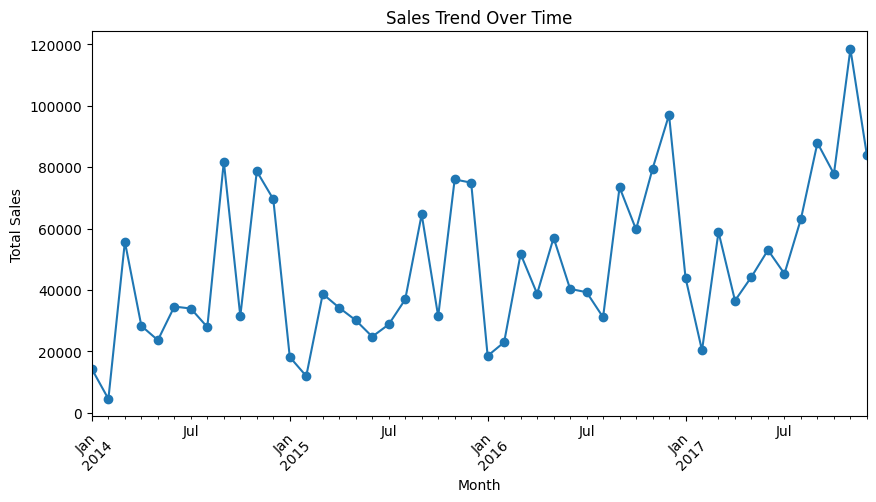

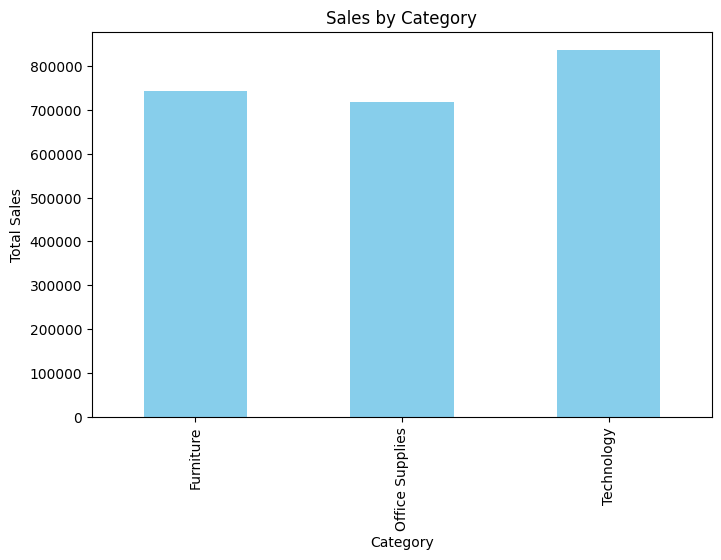

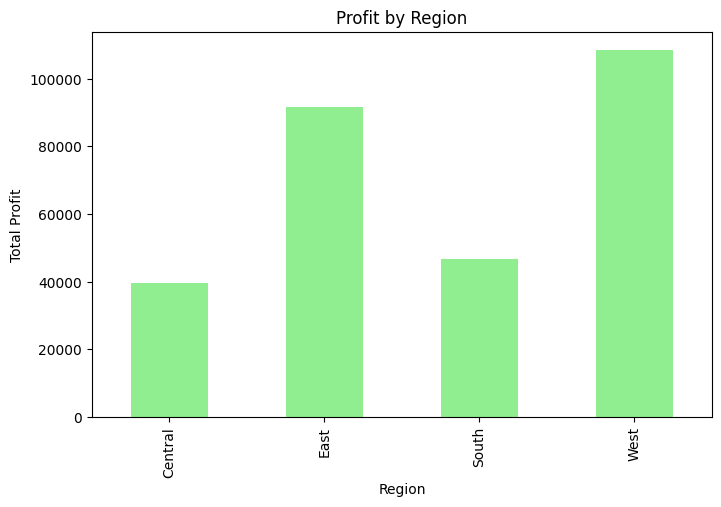

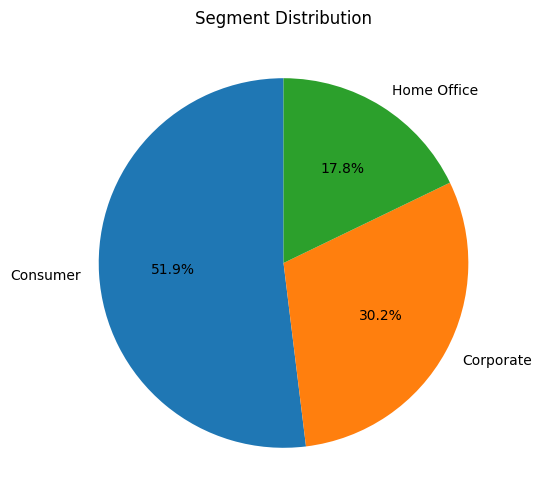

In [13]:
# Task 7: Data Visualization

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset with encoding fix
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Ensure Order Date is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# --- 1. Line chart for sales trend over time ---
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# --- 2. Bar chart for sales by category ---
sales_by_category = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
sales_by_category.plot(kind='bar', color='skyblue')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

# --- 3. Bar chart for profit by region ---
profit_by_region = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
profit_by_region.plot(kind='bar', color='lightgreen')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

# --- 4. Pie chart for segment distribution ---
segment_distribution = df['Segment'].value_counts()

plt.figure(figsize=(6,6))
segment_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Segment Distribution")
plt.ylabel("")  # Hide y-label
plt.show()


 Task 8: Business Insights

 Findings
1. **Most Profitable Category**
   - Identified the category with the highest total profit.
   - This category drives overall profitability and should be prioritized.

2. **Least Performing Region**
   - Determined the region with the lowest profit.
   - Indicates geographic weakness and potential need for strategic review.

3. **Sales–Profit Relationship**
   - Correlation analysis shows how closely sales and profit move together.
   - Positive correlation suggests higher sales generally lead to higher profit, but discounts or costs may weaken the relationship.

4. **Trends Over Time**
   - Monthly analysis reveals fluctuations in sales and profit.
   - Highlights seasonality, growth patterns, and periods of strong or weak performance.

 Why It Matters
- Pinpoints strengths (profitable categories) and weaknesses (underperforming regions).
- Correlation analysis informs pricing and discount strategies.
- Time trends guide forecasting, inventory planning, and marketing campaigns.


In [14]:
# Task 8: Business Insights

import pandas as pd

# Load dataset with encoding fix
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Ensure Order Date is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# 1. Most profitable category
profit_by_category = df.groupby('Category')['Profit'].sum().reset_index()
most_profitable_category = profit_by_category.loc[profit_by_category['Profit'].idxmax()]
print("Most Profitable Category:")
print(most_profitable_category)

# 2. Least performing region (based on profit)
profit_by_region = df.groupby('Region')['Profit'].sum().reset_index()
least_performing_region = profit_by_region.loc[profit_by_region['Profit'].idxmin()]
print("\nLeast Performing Region:")
print(least_performing_region)

# 3. Patterns between sales and profit (correlation)
correlation = df[['Sales', 'Profit']].corr()
print("\nCorrelation between Sales and Profit:")
print(correlation)

# 4. Important trends over time (monthly sales & profit)
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_trends = df.groupby('Order Month')[['Sales', 'Profit']].sum().reset_index()
print("\nMonthly Sales & Profit Trends:")
print(monthly_trends.head())


Most Profitable Category:
Category     Technology
Profit      145454.9481
Name: 2, dtype: object

Least Performing Region:
Region       Central
Profit    39706.3625
Name: 0, dtype: object

Correlation between Sales and Profit:
           Sales    Profit
Sales   1.000000  0.479064
Profit  0.479064  1.000000

Monthly Sales & Profit Trends:
  Order Month      Sales     Profit
0     2014-01  14236.895  2450.1907
1     2014-02   4519.892   862.3084
2     2014-03  55691.009   498.7299
3     2014-04  28295.345  3488.8352
4     2014-05  23648.287  2738.7096
